# Flujo de trabajo básico de regresión con Linear Regression

## Introducción

Este notebook introduce el **flujo de trabajo fundamental de machine learning** para tareas de regresión usando el algoritmo más simple: **Linear Regression**. Nuestro objetivo es entender cada paso a fondo antes de añadir más complejidad.

### ¿Qué es la regresión?

La regresión es una tarea de aprendizaje supervisado donde predecimos un **valor numérico continuo** (no categorías discretas). Ejemplos:
- Predecir precios de casas basándose en sus características
- Pronosticar temperatura o consumo de energía
- Estimar el tiempo de recuperación de un paciente

### El flujo de trabajo completo de ML

Todo proyecto de machine learning sigue estos pasos esenciales:

1. **Cargar y explorar datos**: Entender con qué trabajamos
2. **Dividir los datos**: Separar training y test
3. **Preprocesar los datos**: Escalar las features para mejor rendimiento
4. **Entrenar el modelo**: Ajustar el algoritmo a los datos de training
5. **Evaluar el modelo**: Evaluar el rendimiento en datos de test
6. **Analizar resultados**: Entender predicciones y errores


### Dataset: California Housing

Usaremos el **dataset California Housing**:
- **20,640 observaciones** del censo de California de 1990
- **8 features**: ingreso mediano, antigüedad de la casa, habitaciones, ubicación, etc.
- **Target**: Valor mediano de la casa (en $100,000s)

## 1. Importar las librerías necesarias

Importaremos solo lo necesario para este flujo de trabajo básico.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importaciones de Scikit-learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Métricas de evaluación
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

## 2. Cargar y explorar el dataset

### Features del dataset

El dataset California Housing contiene estas 8 features:

1. **MedInc**: Ingreso mediano del grupo de bloques (en $10,000s)
2. **HouseAge**: Antigüedad mediana de las casas del grupo de bloques (años)
3. **AveRooms**: Número promedio de habitaciones por hogar
4. **AveBedrms**: Número promedio de dormitorios por hogar
5. **Population**: Población del grupo de bloques
6. **AveOccup**: Tamaño promedio del hogar (personas por hogar)
7. **Latitude**: Latitud del grupo de bloques
8. **Longitude**: Longitud del grupo de bloques

**Target**: Valor mediano de la casa (en $100,000s)

### Cargar el dataset

La función `fetch_california_housing()` carga el dataset. Al establecer `as_frame=True`, obtenemos DataFrames de pandas en lugar de arrays de NumPy.

In [2]:
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame
X = housing_data.data  # Features
y = housing_data.target  # Target (valores de las casas)

print(f"Forma: {X.shape[0]:,} observaciones, {X.shape[1]} features")

Forma: 20,640 observaciones, 8 features


### Examinar las primeras filas

Veamos las primeras observaciones para entender la estructura de los datos.

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Resumen estadístico

El método `describe()` muestra estadísticas clave: media, desviación estándar, mínimo, cuartiles y máximo para cada feature.

In [ ]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### Observaciones clave

**Nótese la diferencia de escalas**:
- `MedInc` varía entre ~0.5 y 15
- `Population` varía entre 3 y 35,000+
- `Latitude` varía entre 32 y 42

Estas escalas tan diferentes requerirán **escalado de features** antes del training.

### Distribución de la variable target

Examinemos la variable target (precios de las casas) con más detalle.

In [4]:
print("\nEstadísticas de la variable target (Valor Mediano de la Casa):")
print(f"Media:   ${y.mean() * 100000:,.0f}")
print(f"Mediana: ${y.median() * 100000:,.0f}")
print(f"Mín:     ${y.min() * 100000:,.0f}")
print(f"Máx:     ${y.max() * 100000:,.0f}")
print(f"Desv. estándar:    ${y.std() * 100000:,.0f}")


Estadísticas de la variable target (Valor Mediano de la Casa):
Media:   $206,856
Mediana: $179,700
Mín:     $14,999
Máx:     $500,001
Desv. estándar:    $115,396


### Visualizar la distribución del target

Entender la distribución de los precios de las casas nos ayuda a interpretar el rendimiento del modelo más adelante.

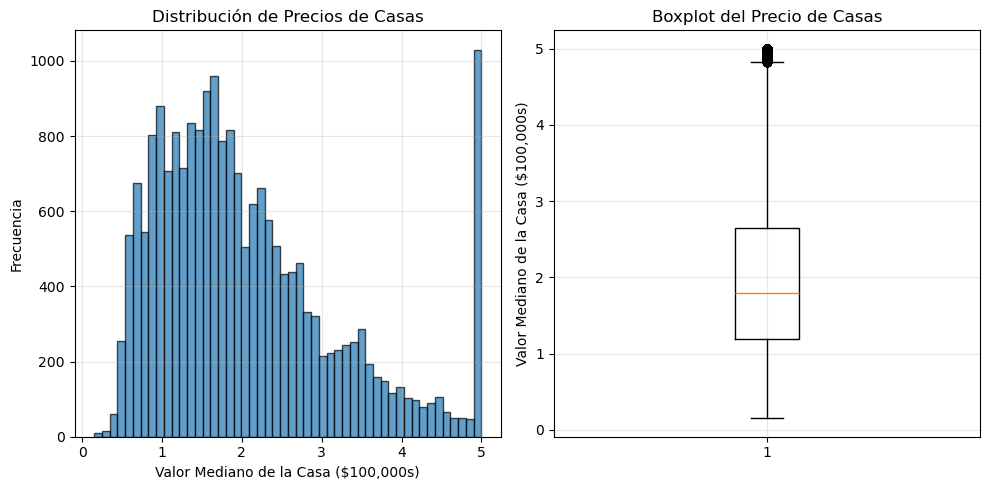

Nota: Los precios están limitados a $500,000 (valor de 5.0)


In [5]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Valor Mediano de la Casa ($100,000s)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Precios de Casas')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(y)
plt.ylabel('Valor Mediano de la Casa ($100,000s)')
plt.title('Boxplot del Precio de Casas')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Nota: Los precios están limitados a $500,000 (valor de 5.0)")

### Correlaciones entre features

¿Qué features tienen la relación más fuerte con los precios de las casas?

In [6]:
print("\nCorrelaciones con el Precio de la Casa (ordenadas por intensidad):")
print("=" * 60)

correlations = df.corr()['MedHouseVal'].sort_values(ascending=False).drop('MedHouseVal')

for feature, corr in correlations.items():
    bar = '█' * int(abs(corr) * 40)
    sign = '+' if corr > 0 else '-'
    print(f"{feature:12s}: {sign}{bar} {corr:6.3f}")

print("\nDato clave: ¡El ingreso mediano tiene la correlación más fuerte!")


Correlaciones con el Precio de la Casa (ordenadas por intensidad):
MedInc      : +███████████████████████████  0.688
AveRooms    : +██████  0.152
HouseAge    : +████  0.106
AveOccup    : - -0.024
Population  : - -0.025
Longitude   : -█ -0.046
AveBedrms   : -█ -0.047
Latitude    : -█████ -0.144

Dato clave: ¡El ingreso mediano tiene la correlación más fuerte!


## 3. Dividir los datos en training y test

### ¿Por qué dividir?

Este es el **principio más fundamental** del machine learning:

1. **Training Set** (80%): Usado para enseñar al modelo
2. **Test Set** (20%): Usado para evaluar el modelo con datos no vistos

**Regla crítica**: El modelo nunca debe ver el test set durante el training. Esto asegura que nuestra evaluación refleje el rendimiento en el mundo real con datos nuevos y no vistos.

### El peligro de no dividir

Si entrenamos y evaluamos en los mismos datos:
- El modelo podría simplemente memorizar los datos de training (**overfitting**)
- No tendríamos idea de cómo funciona con datos nuevos
- Es como estudiar para un examen con exactamente las mismas preguntas que aparecerán

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para test
    random_state=42     # Para reproducibilidad
)

print("Resumen de la división de datos:")
print("=" * 60)
print(f"Total de observaciones:     {len(X):,}")
print(f"Observaciones de training:  {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Observaciones de test:      {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nFormas de las features:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

print(f"\nLas distribuciones del target son similares:")
print(f"  Media de train: ${y_train.mean()*100000:,.0f}")
print(f"  Media de test:  ${y_test.mean()*100000:,.0f}")
print("\nBuena división! Las distribuciones coinciden.")

Resumen de la división de datos:
Total de observaciones:     20,640
Observaciones de training:  16,512 (80.0%)
Observaciones de test:      4,128 (20.0%)

Formas de las features:
  X_train: (16512, 8)
  X_test:  (4128, 8)

Las distribuciones del target son similares:
  Media de train: $207,195
  Media de test:  $205,500

Buena división! Las distribuciones coinciden.


## 4. Preprocesamiento: Escalado de features

### ¿Por qué escalar las features?

La Linear Regression estándar usa una **solución analítica directa** (fórmula de forma cerrada) en lugar de optimización iterativa como Gradient Descent. Esto significa que técnicamente puede encontrar los pesos óptimos sin escalado.

Sin embargo, el escalado sigue siendo una **buena práctica** aquí por:

1. **Interpretación de coeficientes**:
   - `MedInc`: rango 0-15
   - `Population`: rango 3-35,000
   
   Sin escalado, los coeficientes aprendidos estarían en escalas muy diferentes, haciendo imposible comparar qué feature es más "importante" solo mirando los pesos.

2. **Estabilidad numérica**: Previene errores al trabajar con números muy grandes o muy pequeños.

3. **Compatibilidad futura**: Prepara nuestros datos para otros algoritmos (como SGD, SVMs, o Redes Neuronales) que **estrictamente requieren** escalado para converger.

### StandardScaler: La solución

`StandardScaler` transforma cada feature para tener:
- **Media = 0**
- **Desviación estándar = 1**

Fórmula: $z = \frac{x - \mu}{\sigma}$

donde:
- $x$ = valor original
- $\mu$ = media (de los datos de training)
- $\sigma$ = desviación estándar (de los datos de training)

### Paso 1: Crear y ajustar el scaler

Creamos un scaler y lo **ajustamos solo con los datos de training**. Esto calcula la media y la desviación estándar para cada feature.

In [8]:
# Crear el scaler
scaler = StandardScaler()

# Ajustar con los datos de training (aprende media y desviación estándar)
scaler.fit(X_train)

print("Scaler ajustado con los datos de training!")
print("\nParámetros aprendidos (primeras 3 features):")
for i in range(3):
    feature = housing_data.feature_names[i]
    mean = scaler.mean_[i]
    std = scaler.scale_[i]
    print(f"  {feature:10s}: media = {mean:6.2f}, desv. estándar = {std:5.2f}")

Scaler ajustado con los datos de training!

Parámetros aprendidos (primeras 3 features):
  MedInc    : media =   3.88, desv. estándar =  1.90
  HouseAge  : media =  28.61, desv. estándar = 12.60
  AveRooms  : media =   5.44, desv. estándar =  2.39


### Paso 2: Transformar los datos de training

Ahora aplicamos la transformación de escalado a los datos de training.

In [9]:
# Transformar los datos de training
X_train_scaled = scaler.transform(X_train)

print("Datos de training escalados!")
print(f"Forma: {X_train_scaled.shape}")
print(f"\nTras el escalado, cada feature tiene:")
print(f"  Media ≈ 0.0: {X_train_scaled.mean():.6f}")
print(f"  Desv. estándar ≈ 1.0:  {X_train_scaled.std():.6f}")

Datos de training escalados!
Forma: (16512, 8)

Tras el escalado, cada feature tiene:
  Media ≈ 0.0: 0.000000
  Desv. estándar ≈ 1.0:  1.000000


### Paso 3: Transformar los datos de test

**Regla crítica**: Debemos usar la **misma** media y desviación estándar (de los datos de training) para transformar el test set.

**¿Por qué?**
- En producción, los datos nuevos llegan sin etiquetas
- No podemos calcular estadísticas a partir de datos sin etiqueta
- Debemos usar las estadísticas de training que ya aprendimos

**Lo que NO hay que hacer**: Nunca llamar `scaler.fit(X_test)` — esto filtraría información del test!

In [10]:
# Transformar los datos de test usando las estadísticas de training
X_test_scaled = scaler.transform(X_test)  # Nota: solo transform, NO fit_transform!

print("Datos de test escalados usando las estadísticas de training!")
print(f"Forma: {X_test_scaled.shape}")
print("\nImportante: Usamos media/desviación estándar de training, no del test")
print("   Esto previene la fuga de datos y simula el despliegue real.")

Datos de test escalados usando las estadísticas de training!
Forma: (4128, 8)

Importante: Usamos media/desviación estándar de training, no del test
   Esto previene la fuga de datos y simula el despliegue real.


## 5. Entrenar el modelo de Linear Regression

### Cómo funciona la Linear Regression

La Linear Regression encuentra el hiperplano que mejor se ajusta a través de los datos:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

donde:
- $\hat{y}$ = valor predicho de la casa
- $\beta_0$ = término independiente (valor base)
- $\beta_1, ..., \beta_n$ = coeficientes (pesos de las features)
- $x_1, ..., x_n$ = valores de las features (escalados)

El algoritmo minimiza la **suma de errores al cuadrado** entre las predicciones y los valores reales.

In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"\nEl modelo aprendió {len(model.coef_)} coeficientes (uno por feature)")
print(f"Término independiente: {model.intercept_:.4f}")


El modelo aprendió 8 coeficientes (uno por feature)
Término independiente: 2.0719


### Interpretación de los coeficientes del modelo

Cada coeficiente muestra cuánto cambia el target cuando esa feature aumenta en una desviación estándar (ya que escalamos).

In [12]:
print("Importancia de las features (Coeficientes):")
print("=" * 60)

# Crear un DataFrame para mejor visualización
coef_df = pd.DataFrame({
    'Feature': housing_data.feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

for _, row in coef_df.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    sign = '+' if coef > 0 else '-'
    bar = '█' * int(abs(coef) * 10)
    print(f"{feature:12s}: {sign}{bar} {coef:7.4f}")

print("\nInterpretación: ¡El ingreso mediano tiene el impacto positivo más fuerte!")

Importancia de las features (Coeficientes):
Latitude    : -████████ -0.8969
Longitude   : -████████ -0.8698
MedInc      : +████████  0.8544
AveBedrms   : +███  0.3393
AveRooms    : -██ -0.2944
HouseAge    : +█  0.1225
AveOccup    : - -0.0408
Population  : - -0.0023

Interpretación: ¡El ingreso mediano tiene el impacto positivo más fuerte!


## 6. Hacer predicciones

Ahora podemos usar nuestro modelo entrenado para predecir precios de casas en el test set.

In [13]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print(f"Se generaron {len(y_train_pred):,} predicciones en el training set")
print(f"Se generaron {len(y_test_pred):,} predicciones en el test set")

# Mostrar algunas predicciones de ejemplo
print("\nPredicciones de muestra (primeras 5 observaciones del test):")

sample_df = pd.DataFrame({
    'Real': y_test.iloc[:5].values * 100000,
    'Predicho': y_test_pred[:5] * 100000,
    'Error': (y_test.iloc[:5].values - y_test_pred[:5]) * 100000
})

# Formatear como moneda
sample_df['Real'] = sample_df['Real'].apply(lambda x: f"${x:,.0f}")
sample_df['Predicho'] = sample_df['Predicho'].apply(lambda x: f"${x:,.0f}")
sample_df['Error'] = sample_df['Error'].apply(lambda x: f"${x:,.0f}")

sample_df

Se generaron 16,512 predicciones en el training set
Se generaron 4,128 predicciones en el test set

Predicciones de muestra (primeras 5 observaciones del test):


,Real,Predicho,Error
0,"$47,700","$71,912","$-24,212"
1,"$45,800","$176,402","$-130,602"
2,"$500,001","$270,966","$229,035"
3,"$218,600","$283,893","$-65,293"
4,"$278,000","$260,466","$17,534"


## 7. Evaluar el rendimiento del modelo

### Métricas de regresión

Usaremos tres métricas estándar para evaluar nuestro modelo:

1. **Mean Absolute Error (MAE)**: Error promedio de predicción
   - Fórmula: $\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$
   - Interpretación: Error promedio en dólares

2. **Root Mean Squared Error (RMSE)**: Enfatiza errores mayores
   - Fórmula: $\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$
   - Interpretación: Magnitud típica del error

3. **R² Score**: Proporción de varianza explicada
   - Fórmula: $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$
   - Rango: $(-\infty, 1]$ donde 1.0 es perfecto
   - Interpretación: Qué tan bien el modelo explica los datos

In [14]:
# Calcular métricas para el training set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Calcular métricas para el test set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Crear DataFrame de métricas de rendimiento
metrics_df = pd.DataFrame({
    'Métrica': ['Mean Absolute Error', 'Root Mean Squared Error', 'R² Score'],
    'Training': [
        f"${train_mae*100000:,.0f}",
        f"${train_rmse*100000:,.0f}",
        f"{train_r2:.4f}"
    ],
    'Test': [
        f"${test_mae*100000:,.0f}",
        f"${test_rmse*100000:,.0f}",
        f"{test_r2:.4f}"
    ]
})

print("Métricas de rendimiento del modelo:")
display(metrics_df)

print(f"\nInterpretación:")
print(f"  En promedio, las predicciones tienen un error de ${test_mae*100000:,.0f}")
print(f"  El modelo explica el {test_r2*100:.2f}% de la varianza en los precios de las casas")
print(f"  Las métricas de training y test son similares -> buena generalización!")

Métricas de rendimiento del modelo:


,Métrica,Training,Test
0,Mean Absolute Error,"$52,863","$53,320"
1,Root Mean Squared Error,"$71,968","$74,558"
2,R² Score,0.6126,0.5758



Interpretación:
  En promedio, las predicciones tienen un error de $53,320
  El modelo explica el 57.58% de la varianza en los precios de las casas
  Las métricas de training y test son similares -> buena generalización!


### Entendiendo el Overfitting

El **overfitting** ocurre cuando un modelo funciona mucho mejor en los datos de training que en los datos de test.

Señales de overfitting:
- Gran diferencia entre R² de training y test
- Error de training << Error de test

Nuestra Linear Regression muestra **buena generalización** porque las métricas de training y test son similares.

In [15]:
# Verificar el overfitting
r2_gap = train_r2 - test_r2

print("Análisis de Overfitting:")
print("=" * 60)
print(f"R² de training:  {train_r2:.4f}")
print(f"R² de test:      {test_r2:.4f}")
print(f"Diferencia:          {r2_gap:.4f}")

if r2_gap < 0.02:
    print("\nExcelente! No se detecta overfitting.")
elif r2_gap < 0.05:
    print("\nBien! Overfitting mínimo.")
elif r2_gap < 0.10:
    print("\nLeve overfitting presente.")
else:
    print("\nSe detecta overfitting significativo!")

Análisis de Overfitting:
R² de training:  0.6126
R² de test:      0.5758
Diferencia:          0.0368

Bien! Overfitting mínimo.


## 8. Visualizar los resultados

### Valores reales vs. predichos

Este diagrama de dispersión muestra qué tan bien las predicciones coinciden con los valores reales. Los puntos en la línea diagonal representan predicciones perfectas.

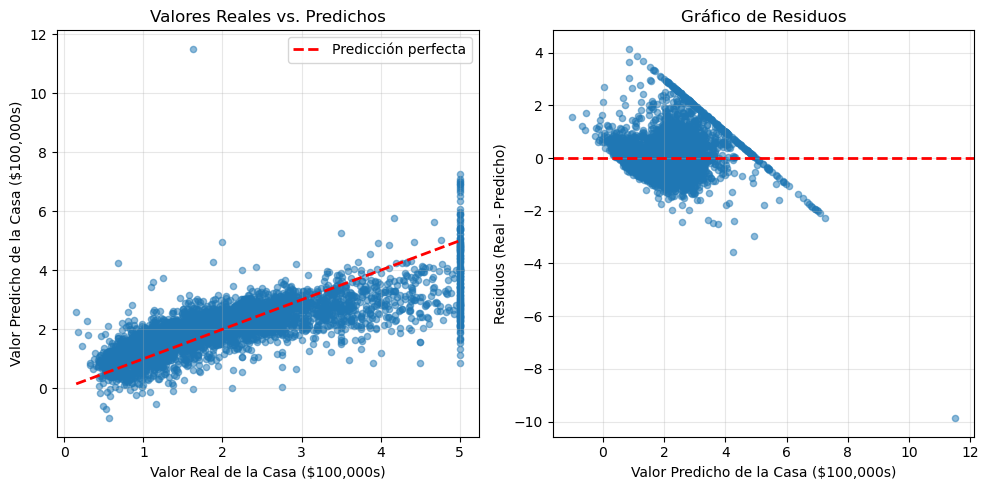


Patrones ideales:
  Gráfico izquierdo: Los puntos se agrupan alrededor de la línea diagonal
  Gráfico derecho: Los residuos dispersos aleatoriamente alrededor de cero


In [16]:
plt.figure(figsize=(10, 5))

# Valores reales vs. predichos
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valor Real de la Casa ($100,000s)')
plt.ylabel('Valor Predicho de la Casa ($100,000s)')
plt.title('Valores Reales vs. Predichos')
plt.legend()
plt.grid(True, alpha=0.3)

# Residuos
plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Valor Predicho de la Casa ($100,000s)')
plt.ylabel('Residuos (Real - Predicho)')
plt.title('Gráfico de Residuos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPatrones ideales:")
print("  Gráfico izquierdo: Los puntos se agrupan alrededor de la línea diagonal")
print("  Gráfico derecho: Los residuos dispersos aleatoriamente alrededor de cero")

### Distribución de errores

Examinemos cómo se distribuyen los errores de predicción.

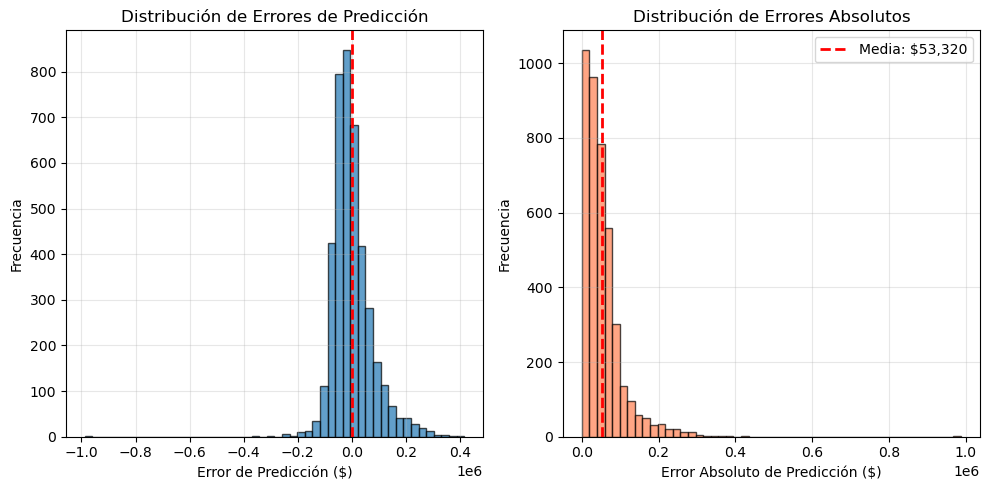


Estadísticas de Error:
  Error medio: $348 (debería estar cerca de $0)
  Error absoluto medio: $53,320
  Mayoría de predicciones dentro de: ±$60,011 (percentil 68)


In [17]:
plt.figure(figsize=(10, 5))

# Distribución de errores
plt.subplot(1, 2, 1)
errors = (y_test - y_test_pred) * 100000
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Error de Predicción ($)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores de Predicción')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(True, alpha=0.3)

# Errores absolutos
plt.subplot(1, 2, 2)
abs_errors = np.abs(errors)
plt.hist(abs_errors, bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Error Absoluto de Predicción ($)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores Absolutos')
plt.axvline(x=abs_errors.mean(), color='r', linestyle='--', lw=2, 
            label=f'Media: ${abs_errors.mean():,.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de Error:")
print(f"  Error medio: ${errors.mean():,.0f} (debería estar cerca de $0)")
print(f"  Error absoluto medio: ${abs_errors.mean():,.0f}")
print(f"  Mayoría de predicciones dentro de: ±${abs_errors.quantile(0.68):,.0f} (percentil 68)")

## 9. Conclusiones

### Lo que aprendimos

1. **El flujo de trabajo de ML**: Cargar → Dividir → Escalar → Entrenar → Evaluar → Analizar

2. **Siempre dividir los datos primero**: Nunca entrenar y evaluar con los mismos datos

3. **El escalado de features importa**: La Linear Regression necesita features escaladas para un rendimiento óptimo

4. **Prevenir la fuga de datos**: Usar las estadísticas de training (media/desviación estándar) para transformar los datos de test

5. **Múltiples métricas**: MAE, RMSE y R² ofrecen diferentes perspectivas sobre el rendimiento

6. **La generalización es clave**: Rendimiento similar en training/test indica buena generalización

7. **Visualizar los resultados**: Los gráficos revelan patrones que las métricas solas podrían pasar por alto

### Fortalezas de la Linear Regression

Simple e interpretable: Los coeficientes muestran la importancia de las features  
Rápida de entrenar: Sin iteraciones complejas  
Buen punto de partida: Otros modelos deberían superar este rendimiento  
Fiable: Resultados consistentes, sin aleatoriedad  

### Limitaciones de la Linear Regression

No asume linealidad: No puede capturar relaciones no lineales complejas  
Sensible a outliers: El error al cuadrado penaliza mucho las grandes desviaciones  
Sin interacciones entre features: Trata las features de forma independiente  

### Qué sigue

Este notebook enseñó el **flujo de trabajo fundamental**. El siguiente introducirá:

1. **Pipelines**: Automatizar preprocesamiento + entrenamiento en un objeto
2. **Múltiples algoritmos**: Comparar Linear Regression con modelos basados en árboles
3. **Validación adecuada**: Usar validation sets para evitar fuga de datos al comparar algoritmos
4. **Cross-Validation**: Estimación de rendimiento más robusta

### Lista de verificación de buenas prácticas

Siempre dividir los datos antes de cualquier preprocesamiento  
Ajustar scaler/preprocesador solo con datos de training  
Usar el mismo preprocesamiento para training y test  
Evaluar con múltiples métricas  
Verificar el overfitting (diferencia entre training y test)  
Visualizar predicciones y residuos  
Establecer random_state para reproducibilidad  
Documentar el proceso claramente  